# California Housing Prices: Linear, Ridge, and Lasso Regression



In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Set visualization style
sns.set_theme(style="whitegrid")

### 1. Data Loading and Exploratory Data Analysis (EDA)

In [34]:
# Load the dataset
df = pd.read_csv('https://raw.githubusercontent.com/Vvijayaragupathy-uno/machinelearning/main/Day-2%20regression/housing.csv')
print(f"Dataset Shape: {df.shape}\n")
df.head()

Dataset Shape: (20640, 10)



,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [35]:
# Check data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [36]:
# Statistical summary of the dataset
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [37]:
# Missing values count
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


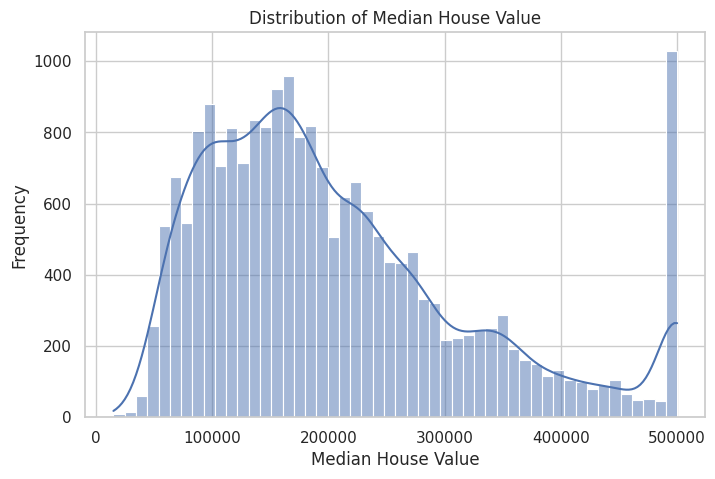

In [38]:
# Visualize the distribution of the target variable
plt.figure(figsize=(8, 5))
sns.histplot(df['median_house_value'], bins=50, kde=True)
plt.title('Distribution of Median House Value')
plt.xlabel('Median House Value')
plt.ylabel('Frequency')
plt.show()

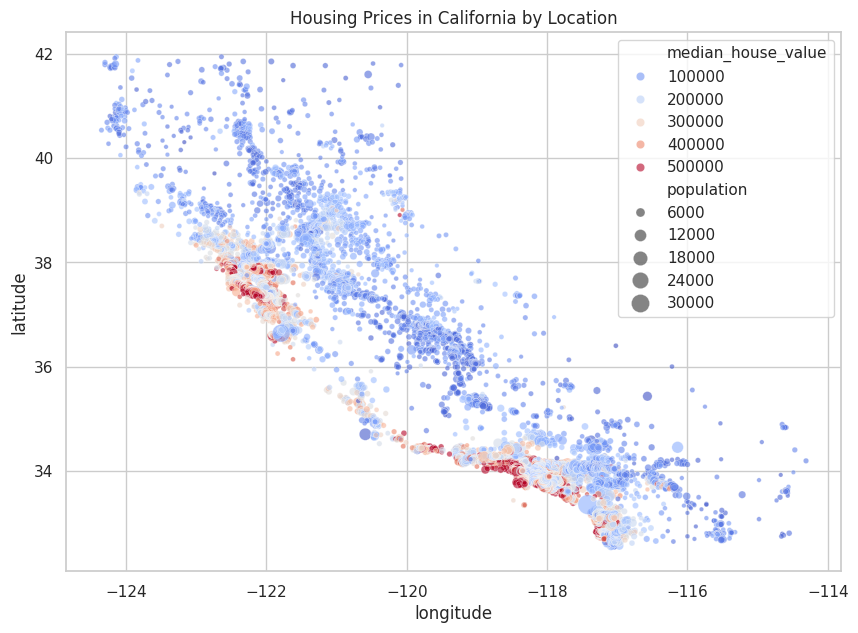

In [39]:
# Visualize housing prices geographically
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df, 
    x='longitude', y='latitude', 
    hue='median_house_value', palette='coolwarm', 
    size='population', sizes=(10, 200), alpha=0.6
)
plt.title('Housing Prices in California by Location')
plt.show()

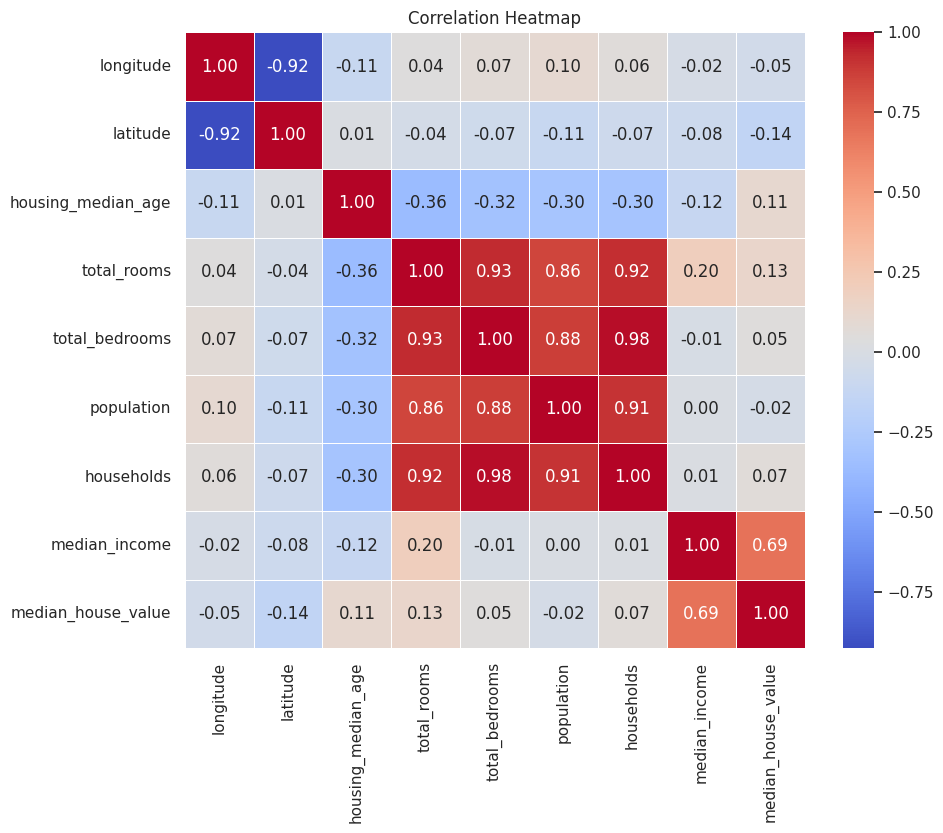

In [40]:
# Correlation matrix to understand relationships between numerical features
plt.figure(figsize=(10, 8))
num_df = df.select_dtypes(include=[np.number])
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

### 2. Feature Engineering
To provide our models with more meaningful signals, we create new composite features based on domain logic.

In [41]:
# Creating new composite features
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']

df[['rooms_per_household', 'bedrooms_per_room', 'population_per_household']].head()

,rooms_per_household,bedrooms_per_room,population_per_household
0,6.984127,0.146591,2.555556
1,6.238137,0.155797,2.109842
2,8.288136,0.129516,2.802260
3,5.817352,0.184458,2.547945
4,6.281853,0.172096,2.181467


### 3. Preprocessing and Train/Test Split

In [42]:
# Separate features and target
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

# Identify numerical and categorical columns
num_cols = X.select_dtypes(include=['float64', 'int64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

# Preprocessing pipelines for numerical and categorical data
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Imputes missing total_bedrooms and bedrooms_per_room
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Bundle preprocessing for numerical and categorical data
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ])

#  Train/test split (80/20) 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocess the data

X_train = preprocessor.fit_transform(X_train)


X_test = preprocessor.transform(X_test)

print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

X_train shape: (16512, 16), X_test shape: (4128, 16)


### 4. Model Building and Evaluation

In [43]:
# Initialize standard Linear Regression
models = {
    'Linear Regression': LinearRegression()
}

# Setup GridSearchCV for Ridge
ridge_params = {'alpha': [0.1, 1.0, 10.0, 50.0, 100.0]}
ridge_grid = GridSearchCV(Ridge(), ridge_params, cv=5, scoring='neg_mean_squared_error')

# Setup GridSearchCV for Lasso
lasso_params = {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0]}
lasso_grid = GridSearchCV(Lasso(max_iter=10000), lasso_params, cv=5, scoring='neg_mean_squared_error')

# Dictionary to store results
results = []

# Train Linear Regression
models['Linear Regression'].fit(X_train, y_train)
y_pred_lr = models['Linear Regression'].predict(X_test)
results.append({'Model': 'Linear Regression', 'MAE': mean_absolute_error(y_test, y_pred_lr), 'MSE': mean_squared_error(y_test, y_pred_lr), 'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_lr)), 'R²': r2_score(y_test, y_pred_lr), 'Best Params': 'N/A'})

# Train and Tune Ridge
print("Tuning Ridge Regression...")
ridge_grid.fit(X_train, y_train)
y_pred_ridge = ridge_grid.predict(X_test)
results.append({'Model': 'Ridge Regression', 'MAE': mean_absolute_error(y_test, y_pred_ridge), 'MSE': mean_squared_error(y_test, y_pred_ridge), 'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_ridge)), 'R²': r2_score(y_test, y_pred_ridge), 'Best Params': str(ridge_grid.best_params_)})
models['Ridge Regression'] = ridge_grid.best_estimator_

# Train and Tune Lasso
print("Tuning Lasso Regression...")
lasso_grid.fit(X_train, y_train)
y_pred_lasso = lasso_grid.predict(X_test)
results.append({'Model': 'Lasso Regression', 'MAE': mean_absolute_error(y_test, y_pred_lasso), 'MSE': mean_squared_error(y_test, y_pred_lasso), 'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_lasso)), 'R²': r2_score(y_test, y_pred_lasso), 'Best Params': str(lasso_grid.best_params_)})
models['Lasso Regression'] = lasso_grid.best_estimator_

# Convert results to DataFrame for comparison
results_df = pd.DataFrame(results)

Tuning Ridge Regression...
Tuning Lasso Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.872e+12, tolerance: 1.755e+10
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.898e+12, tolerance: 1.779e+10
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.939e+12, tolerance: 1.763e

### 5. Comparison Table

In [44]:
# Display the comparison table
results_df.set_index('Model')

,MAE,MSE,RMSE,R²,Best Params
Model,,,,,
Linear Regression,49645.492445,4.778547e+09,69127.038299,0.635339,N/A
Ridge Regression,49652.142873,4.779643e+09,69134.965274,0.635256,{'alpha': 1.0}
Lasso Regression,49646.428893,4.778693e+09,69128.091241,0.635328,{'alpha': 1.0}


### 6. Compare Coefficients

In [45]:
# Get feature names after preprocessing
cat_encoder = preprocessor.named_transformers_['cat']['onehot']
cat_feature_names = cat_encoder.get_feature_names_out(cat_cols)
feature_names = list(num_cols) + list(cat_feature_names)

# Create a DataFrame to compare coefficients
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Linear': models['Linear Regression'].coef_,
    'Ridge': models['Ridge Regression'].coef_,
    'Lasso': models['Lasso Regression'].coef_
})

# Visualizing the impact of regularization on coefficients
coef_df['Abs_Linear'] = coef_df['Linear'].abs()
top_features = coef_df.sort_values(by='Abs_Linear', ascending=False).head(10)
top_features.drop('Abs_Linear', axis=1)

,Feature,Linear,Ridge,Lasso
13,ocean_proximity_ISLAND,112060.244452,93364.871332,126603.019496
7,median_income,78904.439397,78903.857294,78904.879492
1,latitude,-56638.231159,-56586.934719,-56622.795946
0,longitude,-56276.058852,-56221.530409,-56258.340844
12,ocean_proximity_INLAND,-53617.840376,-48971.677482,-34955.884303
5,population,-46320.285471,-46284.328909,-46306.326305
6,households,40233.724848,40073.693458,40207.040476
14,ocean_proximity_NEAR BAY,-24109.185132,-19413.082784,-5424.170186
11,ocean_proximity_<1H OCEAN,-18666.478553,-13996.619361,0.000000
9,bedrooms_per_room,16809.104551,16804.397091,16805.912778


### Conclusion

All three models perform nearly identically with an $R^2$ of ~63.5%, but **Lasso Regression** is the overall best choice because it provides the same accuracy with a simpler equation by automatically zeroing out unnecessary features (like `<1H OCEAN`). While Ridge successfully restrained extreme coefficient spikes (such as the massive `ISLAND` weight seen in standard Linear Regression), Lasso's built-in feature selection offers the most robust and interpretable model for predicting California housing prices.